# Interval Training Diagnostics: Combined Insight Panels Across Sessions

Analyses interval FIT files to reveal rep-level and longitudinal workout quality.

Covers:
- Latest session: power, pace, HR recovery, cardiac drift, and peak HR per rep
- Combined insight panel: normalized multi-metric overlay for the latest run
- All interval dates: date-wise insight comparison (excludes tempo/threshold runs)
- Per-date rep-level panels: within-workout interval breakdown for every session

In [1]:
from pathlib import Path
import pandas as pd

from src.fit_parser import FitParser

cwd = Path.cwd()
candidate_interval_dirs = [
    cwd / 'data' / 'activities' / 'interval' / 'raw',
    cwd.parent / 'data' / 'activities' / 'interval' / 'raw',
]
INTERVAL_DIR = next((p for p in candidate_interval_dirs if p.exists()), candidate_interval_dirs[0])
LAST_N_RUNS = 1


def _pace_min_per_km(row: pd.Series):
    speed_mps = pd.to_numeric(row.get('enhanced_avg_speed'), errors='coerce')
    if pd.notna(speed_mps) and speed_mps > 0:
        return 1000.0 / (float(speed_mps) * 60.0)

    distance_m = pd.to_numeric(row.get('total_distance'), errors='coerce')
    timer_s = pd.to_numeric(row.get('total_timer_time'), errors='coerce')
    if pd.notna(distance_m) and distance_m > 0 and pd.notna(timer_s) and timer_s > 0:
        return (float(timer_s) / 60.0) / (float(distance_m) / 1000.0)

    return pd.NA


def _format_pace(value):
    if pd.isna(value):
        return pd.NA
    minutes = int(value)
    seconds = int(round((float(value) - minutes) * 60))
    if seconds == 60:
        minutes += 1
        seconds = 0
    return f'{minutes:02d}:{seconds:02d} /km'


def _lap_message(row: pd.Series) -> str:
    intensity = str(row.get('intensity', '')).strip().lower()

    if intensity == 'warmup':
        return 'warmup'
    if intensity == 'cooldown':
        return 'cool down'
    if intensity in {'active'}:
        return 'run'
    if intensity in {'recovery', 'rest', '4'}:
        return 'recovery'

    distance_m = pd.to_numeric(row.get('total_distance'), errors='coerce')
    if pd.notna(distance_m) and distance_m < 300:
        return 'recovery'

    return 'run'

In [2]:
fit_files = sorted(
    INTERVAL_DIR.glob('*.fit'),
    key=lambda p: p.stat().st_mtime
)

if not fit_files:
    raise FileNotFoundError(f'No FIT files found in {INTERVAL_DIR}')

selected_files = fit_files[-LAST_N_RUNS:]
print('Selected latest interval run(s):')
for file_path in selected_files:
    print(' -', file_path.name)

frames = []
for file_path in selected_files:
    parser = FitParser(file_path)
    parser.parse()
    laps = parser.laps.copy()

    if laps.empty:
        continue

    laps = laps.reset_index(drop=True)
    laps['laps'] = laps.index + 1
    laps['laps_message'] = laps.apply(_lap_message, axis=1)
    laps['index'] = pd.to_numeric(laps.get('message_index'), errors='coerce').astype('Int64')
    laps['distance'] = pd.to_numeric(laps.get('total_distance'), errors='coerce').round(2)
    laps['lap_avg_pace'] = laps.apply(_pace_min_per_km, axis=1).map(_format_pace)

    out = laps[['laps', 'laps_message', 'index', 'distance', 'lap_avg_pace']].copy()
    frames.append(out)

if not frames:
    raise ValueError('No lap rows found in selected interval run(s).')

result = pd.concat(frames, ignore_index=True)
display(result)
print('\nLaps only output:')
print(result.to_string(index=False))

Selected latest interval run(s):
 - 2026-06-25_thursday_interval.fit


,laps,laps_message,index,distance,lap_avg_pace
0,1,warmup,0,1000.00,07:36 /km
1,2,warmup,1,1000.00,07:56 /km
2,3,run,2,1000.00,06:00 /km
3,4,run,3,600.00,05:57 /km
4,5,recovery,4,292.68,13:40 /km
5,6,run,5,1000.00,06:01 /km
6,7,run,6,600.00,05:57 /km
7,8,recovery,7,291.74,13:42 /km
8,9,run,8,1000.00,05:53 /km
9,10,run,9,600.00,05:59 /km



Laps only output:
 laps laps_message  index  distance lap_avg_pace
    1       warmup      0   1000.00    07:36 /km
    2       warmup      1   1000.00    07:56 /km
    3          run      2   1000.00    06:00 /km
    4          run      3    600.00    05:57 /km
    5     recovery      4    292.68    13:40 /km
    6          run      5   1000.00    06:01 /km
    7          run      6    600.00    05:57 /km
    8     recovery      7    291.74    13:42 /km
    9          run      8   1000.00    05:53 /km
   10          run      9    600.00    05:59 /km
   11    cool down     10   1000.00    09:30 /km
   12    cool down     11    310.19    07:42 /km


## Interval Performance Charts

The following charts are generated from the latest interval FIT file:
1. Rep power consistency
2. HR recovery between reps
3. Cardiac drift across reps
4. Peak HR progression
5. Rep pace consistency

Workout - 25-Jun-26
 |- Warm Up
 |- Repeat 3 Times
 |   |- Run 1600m
 |   \- Recover 4 min
 \- Cool Down


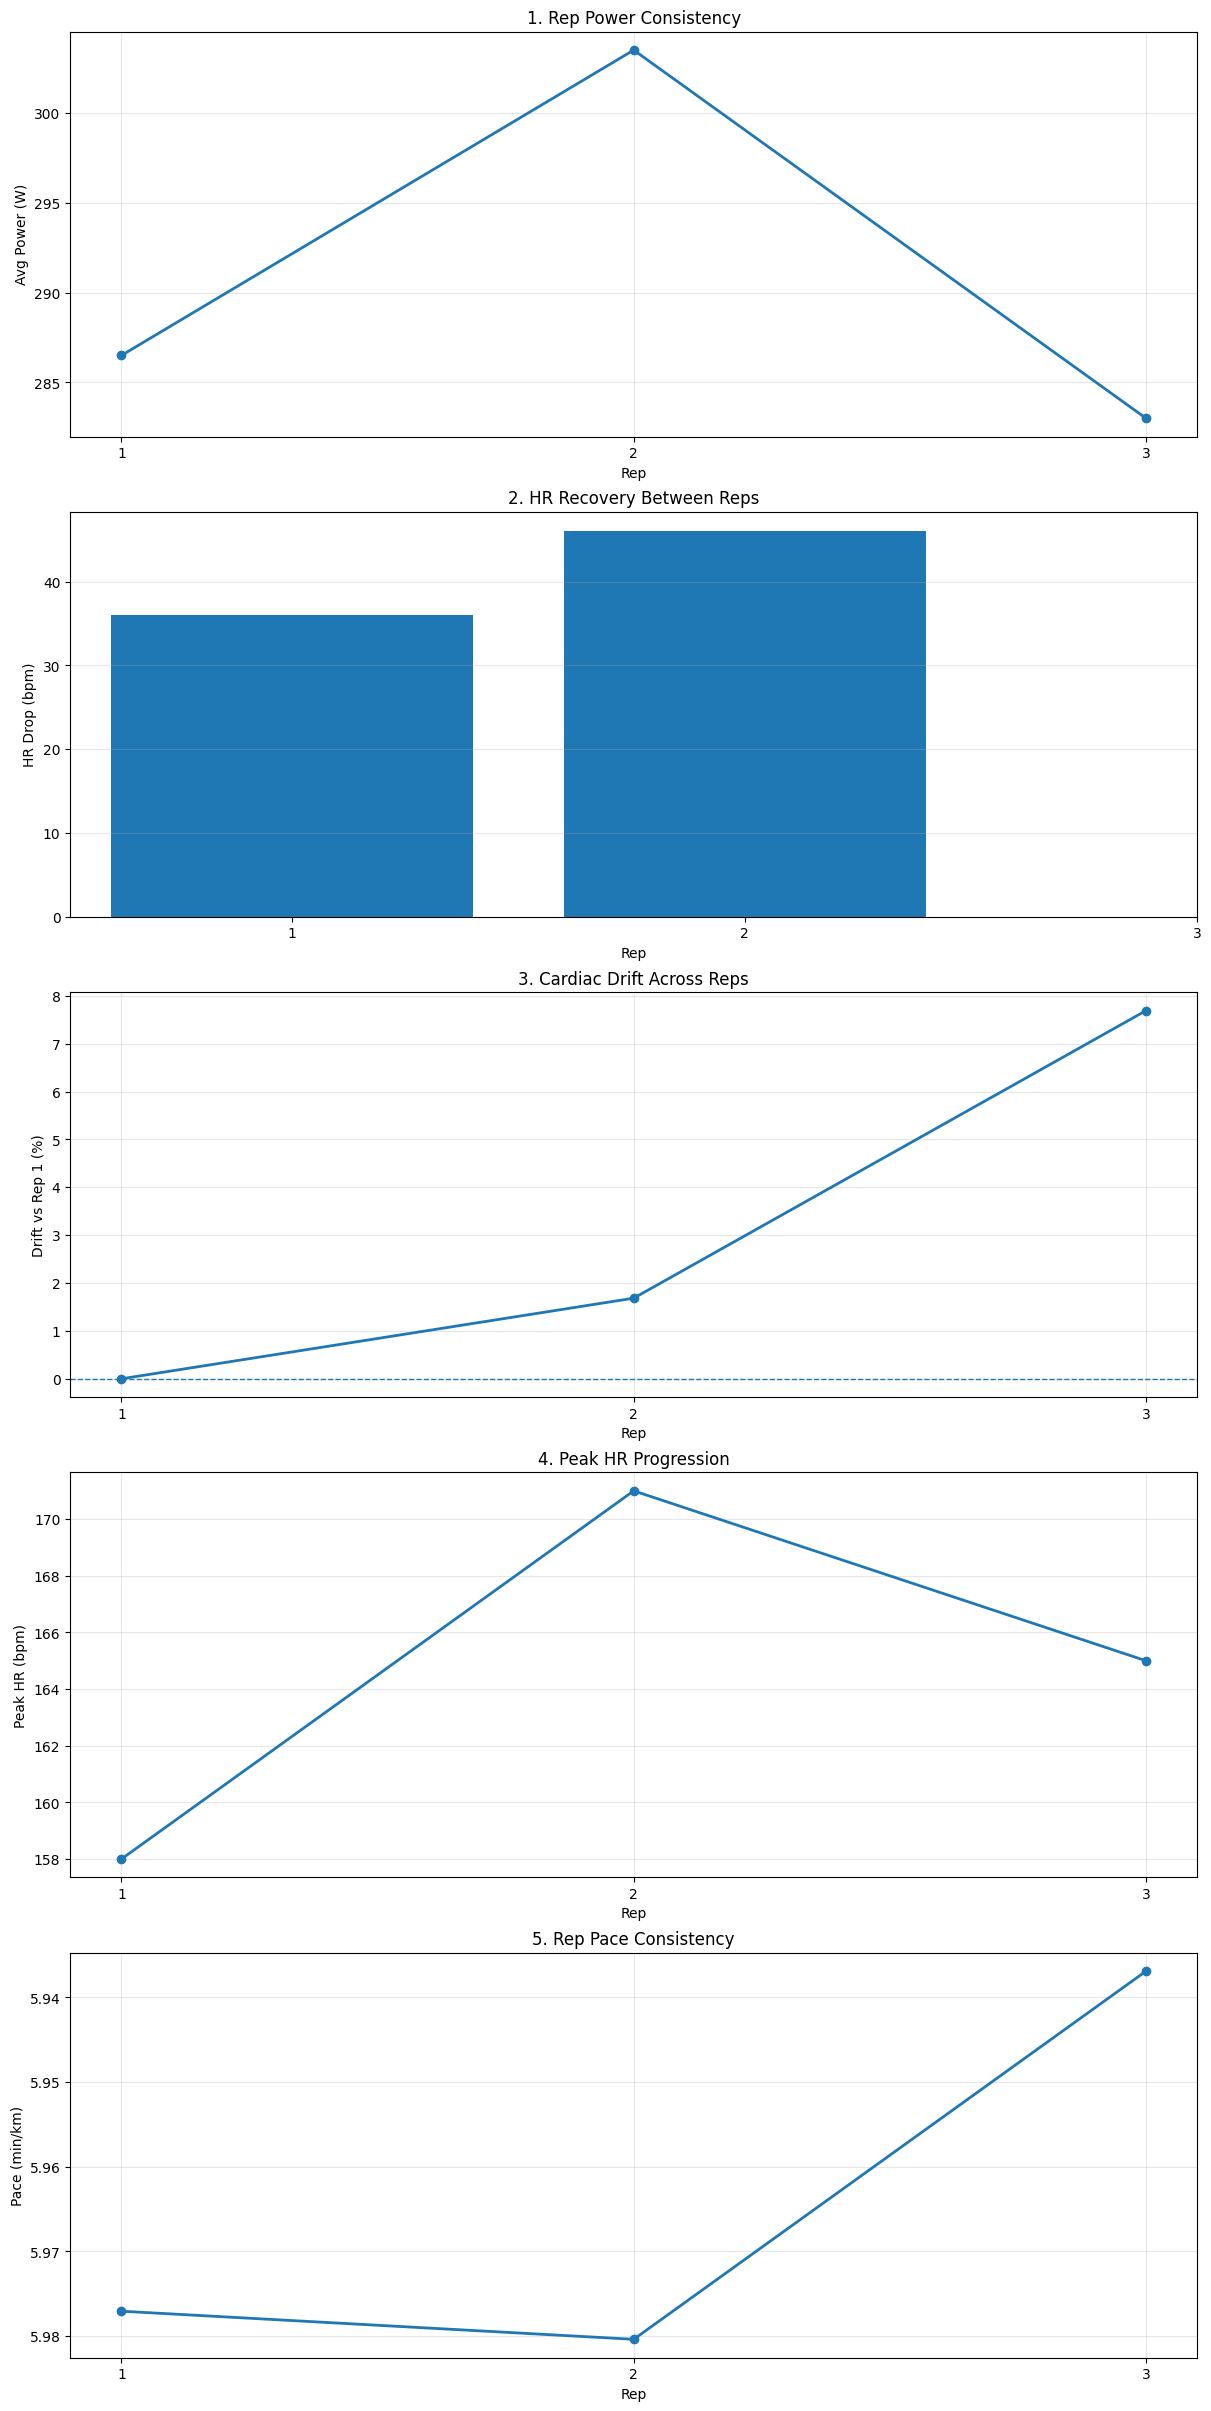

,rep,run_lap_count,run_distance_m,avg_power,avg_hr,max_hr,pace_min_per_km,hr_recovery_drop_bpm,cardiac_drift_pct
0,1,2,1600.0,286.5,149.0,158.0,5.977049,36.0,0.000000
1,2,2,1600.0,303.5,160.5,171.0,5.980368,46.0,1.684486
2,3,2,1600.0,283.0,158.5,165.0,5.936896,NaN,7.691441


In [3]:
import numpy as np
import matplotlib.pyplot as plt

fit_files = sorted(
    INTERVAL_DIR.glob('*.fit'),
    key=lambda p: p.stat().st_mtime,
)

if not fit_files:
    raise FileNotFoundError(f'No FIT files found in {INTERVAL_DIR}')

latest_file = fit_files[-1]
parser = FitParser(latest_file)
parser.parse()
laps_full = parser.laps.copy().reset_index(drop=True)

if laps_full.empty:
    raise ValueError('No lap rows found in the latest interval run.')


def _pace_min_per_km_numeric(row: pd.Series):
    speed_mps = pd.to_numeric(row.get('enhanced_avg_speed'), errors='coerce')
    if pd.notna(speed_mps) and speed_mps > 0:
        return 1000.0 / (float(speed_mps) * 60.0)

    distance_m = pd.to_numeric(row.get('total_distance'), errors='coerce')
    timer_s = pd.to_numeric(row.get('total_timer_time'), errors='coerce')
    if pd.notna(distance_m) and distance_m > 0 and pd.notna(timer_s) and timer_s > 0:
        return (float(timer_s) / 60.0) / (float(distance_m) / 1000.0)

    return np.nan


def _lap_label(row: pd.Series) -> str:
    intensity = str(row.get('intensity', '')).strip().lower()

    if intensity in {'recovery', 'rest', '4'}:
        return 'recovery'
    if intensity == 'warmup':
        return 'warmup'
    if intensity == 'cooldown':
        return 'cooldown'

    distance_m = pd.to_numeric(row.get('total_distance'), errors='coerce')
    if pd.notna(distance_m) and distance_m < 300:
        return 'recovery'

    return 'run'


def _safe_mean(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors='coerce').dropna()
    return float(s.mean()) if not s.empty else np.nan


laps_full['lap_type'] = laps_full.apply(_lap_label, axis=1)
laps_full['lap_number'] = np.arange(1, len(laps_full) + 1)
laps_full['avg_power'] = pd.to_numeric(laps_full.get('avg_power'), errors='coerce')
laps_full['avg_hr'] = pd.to_numeric(laps_full.get('avg_heart_rate'), errors='coerce')
laps_full['max_hr'] = pd.to_numeric(laps_full.get('max_heart_rate'), errors='coerce')
laps_full['distance_m'] = pd.to_numeric(laps_full.get('total_distance'), errors='coerce')
laps_full['timer_s'] = pd.to_numeric(laps_full.get('total_timer_time'), errors='coerce')
laps_full['pace_min_per_km'] = laps_full.apply(_pace_min_per_km_numeric, axis=1)

# Collapse consecutive run laps into one single rep by averaging run metrics.
rep_rows = []
run_buffer = []
rep_index = 0

for _, lap in laps_full.iterrows():
    lap_type = lap['lap_type']

    if lap_type == 'run':
        run_buffer.append(lap)
        continue

    if run_buffer:
        rep_index += 1
        run_df = pd.DataFrame(run_buffer)
        rep_rows.append({
            'rep': rep_index,
            'run_lap_count': int(len(run_df)),
            'avg_power': _safe_mean(run_df['avg_power']),
            'avg_hr': _safe_mean(run_df['avg_hr']),
            'max_hr': float(pd.to_numeric(run_df['max_hr'], errors='coerce').max()),
            'pace_min_per_km': _safe_mean(run_df['pace_min_per_km']),
            'run_distance_m': float(pd.to_numeric(run_df['distance_m'], errors='coerce').sum()),
            'run_time_s': float(pd.to_numeric(run_df['timer_s'], errors='coerce').sum()),
            'recovery_avg_hr': np.nan,
            'recovery_time_s': np.nan,
        })
        run_buffer = []

    if lap_type == 'recovery' and rep_rows:
        rep_rows[-1]['recovery_avg_hr'] = pd.to_numeric(lap.get('avg_hr'), errors='coerce')
        rep_rows[-1]['recovery_time_s'] = pd.to_numeric(lap.get('timer_s'), errors='coerce')

# Flush trailing run buffer if workout ends without a final recovery lap.
if run_buffer:
    rep_index += 1
    run_df = pd.DataFrame(run_buffer)
    rep_rows.append({
        'rep': rep_index,
        'run_lap_count': int(len(run_df)),
        'avg_power': _safe_mean(run_df['avg_power']),
        'avg_hr': _safe_mean(run_df['avg_hr']),
        'max_hr': float(pd.to_numeric(run_df['max_hr'], errors='coerce').max()),
        'pace_min_per_km': _safe_mean(run_df['pace_min_per_km']),
        'run_distance_m': float(pd.to_numeric(run_df['distance_m'], errors='coerce').sum()),
        'run_time_s': float(pd.to_numeric(run_df['timer_s'], errors='coerce').sum()),
        'recovery_avg_hr': np.nan,
        'recovery_time_s': np.nan,
    })

runs = pd.DataFrame(rep_rows)

if runs.empty:
    raise ValueError('No run reps detected in the latest interval run.')

runs['hr_recovery_drop_bpm'] = runs['max_hr'] - runs['recovery_avg_hr']

# Cardiac drift proxy: HR-to-power ratio progression across reps.
runs['hr_power_ratio'] = runs['avg_hr'] / runs['avg_power']
first_ratio = runs['hr_power_ratio'].iloc[0] if pd.notna(runs['hr_power_ratio'].iloc[0]) else np.nan
if pd.notna(first_ratio) and first_ratio != 0:
    runs['cardiac_drift_pct'] = (runs['hr_power_ratio'] / first_ratio - 1.0) * 100.0
else:
    runs['cardiac_drift_pct'] = np.nan

# Workout structure header for quick readability.
has_warmup = (laps_full['lap_type'] == 'warmup').any()
has_cooldown = (laps_full['lap_type'] == 'cooldown').any()
repeat_times = int(len(runs))
avg_run_distance_m = _safe_mean(runs['run_distance_m'])
avg_recovery_time_s = _safe_mean(runs['recovery_time_s'])

start_candidates = pd.to_datetime(laps_full.get('start_time'), errors='coerce')
start_candidates = start_candidates.dropna() if start_candidates is not None else pd.Series(dtype='datetime64[ns]')
if len(start_candidates) > 0:
    # Use the median lap start as the session date anchor to avoid off-by-one on UTC-midnight crossings.
    workout_dt = start_candidates.sort_values().iloc[len(start_candidates) // 2]
else:
    workout_dt = pd.to_datetime(latest_file.stat().st_mtime, unit='s')
workout_date_text = workout_dt.strftime('%d-%b-%y')

print(f'Workout - {workout_date_text}')
if has_warmup:
    print(' |- Warm Up')
print(f' |- Repeat {repeat_times} Times')
print(f" |   |- Run {int(round(avg_run_distance_m, 0))}m")
if pd.notna(avg_recovery_time_s):
    print(f" |   \\- Recover {int(round(avg_recovery_time_s / 60.0, 0))} min")
else:
    print(' |   \\- Recover (not detected)')
if has_cooldown:
    print(' \\- Cool Down')

fig, axes = plt.subplots(5, 1, figsize=(12, 24), constrained_layout=True)

# 1) Rep power consistency
axes[0].plot(runs['rep'], runs['avg_power'], marker='o', linewidth=2)
axes[0].set_title('1. Rep Power Consistency')
axes[0].set_xlabel('Rep')
axes[0].set_ylabel('Avg Power (W)')
axes[0].grid(alpha=0.3)

# 2) HR recovery between reps
axes[1].bar(runs['rep'], runs['hr_recovery_drop_bpm'])
axes[1].set_title('2. HR Recovery Between Reps')
axes[1].set_xlabel('Rep')
axes[1].set_ylabel('HR Drop (bpm)')
axes[1].grid(axis='y', alpha=0.3)

# 3) Cardiac drift across reps
axes[2].plot(runs['rep'], runs['cardiac_drift_pct'], marker='o', linewidth=2)
axes[2].axhline(0, linestyle='--', linewidth=1)
axes[2].set_title('3. Cardiac Drift Across Reps')
axes[2].set_xlabel('Rep')
axes[2].set_ylabel('Drift vs Rep 1 (%)')
axes[2].grid(alpha=0.3)

# 4) Peak HR progression
axes[3].plot(runs['rep'], runs['max_hr'], marker='o', linewidth=2)
axes[3].set_title('4. Peak HR Progression')
axes[3].set_xlabel('Rep')
axes[3].set_ylabel('Peak HR (bpm)')
axes[3].grid(alpha=0.3)

# 5) Rep pace consistency
axes[4].plot(runs['rep'], runs['pace_min_per_km'], marker='o', linewidth=2)
axes[4].set_title('5. Rep Pace Consistency')
axes[4].set_xlabel('Rep')
axes[4].set_ylabel('Pace (min/km)')
axes[4].invert_yaxis()  # Faster pace is better (lower min/km).
axes[4].grid(alpha=0.3)

for ax in axes:
    ax.set_xticks(runs['rep'])

plt.show()

display(
    runs[[
        'rep',
        'run_lap_count',
        'run_distance_m',
        'avg_power',
        'avg_hr',
        'max_hr',
        'pace_min_per_km',
        'hr_recovery_drop_bpm',
        'cardiac_drift_pct',
    ]]
)

## Combined Insight Panel

This panel overlays the most informative metrics on one normalized chart:
- Power consistency
- Cardiac drift
- HR recovery
- Pace consistency (inverted so better pace trends upward)

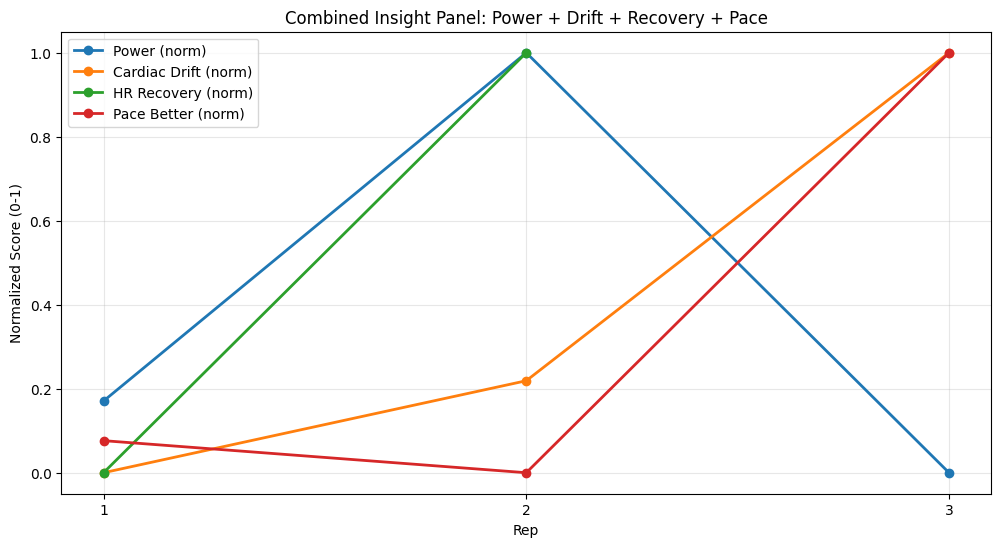

,rep,avg_power,cardiac_drift_pct,hr_recovery_drop_bpm,pace_min_per_km,power_norm,drift_norm,recovery_norm,pace_better_norm
0,1,286.5,0.000000,36.0,5.977049,0.170732,0.000000,0.0,0.076353
1,2,303.5,1.684486,46.0,5.980368,1.000000,0.219008,1.0,0.000000
2,3,283.0,7.691441,NaN,5.936896,0.000000,1.000000,NaN,1.000000


In [4]:
if 'runs' not in globals() or runs.empty:
    raise ValueError('Run Cell 5 first to build the runs dataframe.')

insight = runs[['rep', 'avg_power', 'cardiac_drift_pct', 'hr_recovery_drop_bpm', 'pace_min_per_km']].copy()


def _minmax(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    s_min = s.min(skipna=True)
    s_max = s.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s_min) / (s_max - s_min)


insight['power_norm'] = _minmax(insight['avg_power'])
insight['drift_norm'] = _minmax(insight['cardiac_drift_pct'])
insight['recovery_norm'] = _minmax(insight['hr_recovery_drop_bpm'])
# Lower pace min/km is better, so invert before normalizing.
insight['pace_better_norm'] = _minmax(-insight['pace_min_per_km'])

plt.figure(figsize=(12, 6))
plt.plot(insight['rep'], insight['power_norm'], marker='o', linewidth=2, label='Power (norm)')
plt.plot(insight['rep'], insight['drift_norm'], marker='o', linewidth=2, label='Cardiac Drift (norm)')
plt.plot(insight['rep'], insight['recovery_norm'], marker='o', linewidth=2, label='HR Recovery (norm)')
plt.plot(insight['rep'], insight['pace_better_norm'], marker='o', linewidth=2, label='Pace Better (norm)')

plt.title('Combined Insight Panel: Power + Drift + Recovery + Pace')
plt.xlabel('Rep')
plt.ylabel('Normalized Score (0-1)')
plt.xticks(insight['rep'])
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

display(
    insight[[
        'rep',
        'avg_power',
        'cardiac_drift_pct',
        'hr_recovery_drop_bpm',
        'pace_min_per_km',
        'power_norm',
        'drift_norm',
        'recovery_norm',
        'pace_better_norm',
    ]]
)

## Combined Insight Panel (All Interval Dates)

This section scans all FIT files in the folder and keeps only interval sessions.

Filter logic:
- Do not exclude by filename labels (tempo/threshold/interval)
- Keep sessions with interval-like structure (run/recovery repetitions)

Output:
- Included interval sessions by date
- Excluded sessions with reasons
- Date-wise combined normalized insight panel

Included interval sessions:


,date_text,file,name_hint,reps
0,28-Apr-26,2026-04-28_tuesday_interval.fit,,5
1,05-May-26,2026-05-05_tuesday_interval.fit,,5
2,12-May-26,2026-05-12_tuesday_interval.fit,,8
3,19-May-26,2026-05-19_tuesday_interval.fit,,8
4,26-May-26,2026-05-26_tuesday_interval.fit,,10
5,06-Jun-26,2026-06-06_saturday_interval.fit,,6
6,18-Jun-26,2026-06-18_thursday_threshold.fit,tempo/threshold in filename,8
7,25-Jun-26,2026-06-25_thursday_interval.fit,,3


Excluded sessions (structure/data quality checks):


,file,reason
0,2026-05-16_saturday_threshold.fit,"non-interval structure (reps=1, recovery_pairs..."
1,2026-05-30_saturday_tempo.fit,"non-interval structure (reps=1, recovery_pairs..."
2,2026-06-20_saturday_threshold.fit,"non-interval structure (reps=1, recovery_pairs..."


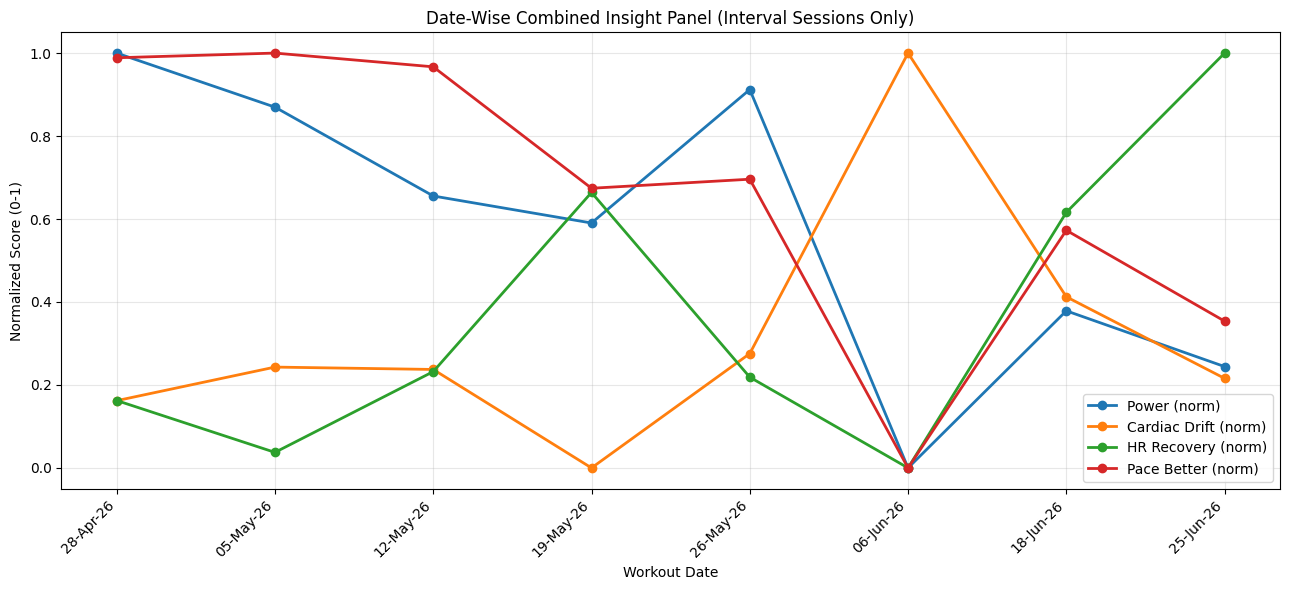

,date_text,reps,avg_power,avg_drift_pct,avg_hr_recovery_drop_bpm,avg_pace_min_per_km,power_norm,drift_norm,recovery_norm,pace_better_norm
0,28-Apr-26,5,314.200,2.714652,27.600000,5.462772,1.000000,0.162137,0.162500,0.988701
1,05-May-26,5,310.200,3.333159,25.600000,5.453838,0.869707,0.243073,0.037500,1.000000
2,12-May-26,8,303.625,3.289688,28.714286,5.480021,0.655537,0.237385,0.232143,0.966886
3,19-May-26,8,301.625,1.475614,35.625000,5.711488,0.590391,0.000000,0.664062,0.674145
4,26-May-26,10,311.500,3.581500,28.500000,5.694237,0.912052,0.275570,0.218750,0.695963
5,06-Jun-26,6,283.500,9.117537,25.000000,6.244527,0.000000,1.000000,0.000000,0.000000
6,18-Jun-26,8,295.125,4.627674,34.857143,5.791648,0.378664,0.412470,0.616071,0.572765
7,25-Jun-26,3,291.000,3.125309,41.000000,5.964771,0.244300,0.215874,1.000000,0.353813


In [5]:
all_fit_files = sorted(
    INTERVAL_DIR.glob('*.fit'),
    key=lambda p: p.stat().st_mtime,
)

if not all_fit_files:
    raise FileNotFoundError(f'No FIT files found in {INTERVAL_DIR}')


def _lap_label_local(row: pd.Series) -> str:
    intensity = str(row.get('intensity', '')).strip().lower()

    if intensity in {'recovery', 'rest', '4'}:
        return 'recovery'
    if intensity == 'warmup':
        return 'warmup'
    if intensity == 'cooldown':
        return 'cooldown'

    distance_m = pd.to_numeric(row.get('total_distance'), errors='coerce')
    if pd.notna(distance_m) and distance_m < 300:
        return 'recovery'

    return 'run'


def _pace_min_per_km_numeric_local(row: pd.Series):
    speed_mps = pd.to_numeric(row.get('enhanced_avg_speed'), errors='coerce')
    if pd.notna(speed_mps) and speed_mps > 0:
        return 1000.0 / (float(speed_mps) * 60.0)

    distance_m = pd.to_numeric(row.get('total_distance'), errors='coerce')
    timer_s = pd.to_numeric(row.get('total_timer_time'), errors='coerce')
    if pd.notna(distance_m) and distance_m > 0 and pd.notna(timer_s) and timer_s > 0:
        return (float(timer_s) / 60.0) / (float(distance_m) / 1000.0)

    return np.nan


def _safe_mean_local(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors='coerce').dropna()
    return float(s.mean()) if not s.empty else np.nan


def _minmax_local(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    s_min = s.min(skipna=True)
    s_max = s.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s_min) / (s_max - s_min)


def _build_reps_from_laps(laps_df: pd.DataFrame) -> pd.DataFrame:
    rep_rows = []
    run_buffer = []
    rep_index = 0

    for _, lap in laps_df.iterrows():
        lap_type = lap['lap_type']

        if lap_type == 'run':
            run_buffer.append(lap)
            continue

        if run_buffer:
            rep_index += 1
            run_df = pd.DataFrame(run_buffer)
            rep_rows.append({
                'rep': rep_index,
                'run_lap_count': int(len(run_df)),
                'avg_power': _safe_mean_local(run_df['avg_power']),
                'avg_hr': _safe_mean_local(run_df['avg_hr']),
                'max_hr': float(pd.to_numeric(run_df['max_hr'], errors='coerce').max()),
                'pace_min_per_km': _safe_mean_local(run_df['pace_min_per_km']),
                'run_distance_m': float(pd.to_numeric(run_df['distance_m'], errors='coerce').sum()),
                'run_time_s': float(pd.to_numeric(run_df['timer_s'], errors='coerce').sum()),
                'recovery_avg_hr': np.nan,
                'recovery_time_s': np.nan,
            })
            run_buffer = []

        if lap_type == 'recovery' and rep_rows:
            rep_rows[-1]['recovery_avg_hr'] = pd.to_numeric(lap.get('avg_hr'), errors='coerce')
            rep_rows[-1]['recovery_time_s'] = pd.to_numeric(lap.get('timer_s'), errors='coerce')

    if run_buffer:
        rep_index += 1
        run_df = pd.DataFrame(run_buffer)
        rep_rows.append({
            'rep': rep_index,
            'run_lap_count': int(len(run_df)),
            'avg_power': _safe_mean_local(run_df['avg_power']),
            'avg_hr': _safe_mean_local(run_df['avg_hr']),
            'max_hr': float(pd.to_numeric(run_df['max_hr'], errors='coerce').max()),
            'pace_min_per_km': _safe_mean_local(run_df['pace_min_per_km']),
            'run_distance_m': float(pd.to_numeric(run_df['distance_m'], errors='coerce').sum()),
            'run_time_s': float(pd.to_numeric(run_df['timer_s'], errors='coerce').sum()),
            'recovery_avg_hr': np.nan,
            'recovery_time_s': np.nan,
        })

    return pd.DataFrame(rep_rows)


included_sessions = []
excluded_sessions = []

for file_path in all_fit_files:
    name_lower = file_path.name.lower()

    parser = FitParser(file_path)
    parser.parse()
    laps_df = parser.laps.copy().reset_index(drop=True)

    if laps_df.empty:
        excluded_sessions.append({'file': file_path.name, 'reason': 'empty laps'})
        continue

    laps_df['lap_type'] = laps_df.apply(_lap_label_local, axis=1)
    laps_df['avg_power'] = pd.to_numeric(laps_df.get('avg_power'), errors='coerce')
    laps_df['avg_hr'] = pd.to_numeric(laps_df.get('avg_heart_rate'), errors='coerce')
    laps_df['max_hr'] = pd.to_numeric(laps_df.get('max_heart_rate'), errors='coerce')
    laps_df['distance_m'] = pd.to_numeric(laps_df.get('total_distance'), errors='coerce')
    laps_df['timer_s'] = pd.to_numeric(laps_df.get('total_timer_time'), errors='coerce')
    laps_df['pace_min_per_km'] = laps_df.apply(_pace_min_per_km_numeric_local, axis=1)

    reps_df = _build_reps_from_laps(laps_df)

    if reps_df.empty:
        excluded_sessions.append({'file': file_path.name, 'reason': 'no run reps'})
        continue

    reps_df['hr_recovery_drop_bpm'] = reps_df['max_hr'] - reps_df['recovery_avg_hr']
    reps_df['hr_power_ratio'] = reps_df['avg_hr'] / reps_df['avg_power']
    first_ratio = reps_df['hr_power_ratio'].iloc[0] if pd.notna(reps_df['hr_power_ratio'].iloc[0]) else np.nan
    if pd.notna(first_ratio) and first_ratio != 0:
        reps_df['cardiac_drift_pct'] = (reps_df['hr_power_ratio'] / first_ratio - 1.0) * 100.0
    else:
        reps_df['cardiac_drift_pct'] = np.nan

    recovery_count = int(reps_df['recovery_avg_hr'].notna().sum())
    median_run_distance = float(pd.to_numeric(reps_df['run_distance_m'], errors='coerce').median())
    reps_count = int(len(reps_df))

    # Interval classifier: repeated run-recovery structure with non-long run reps.
    is_interval = (
        reps_count >= 3
        and recovery_count >= 2
        and pd.notna(median_run_distance)
        and median_run_distance <= 3000
    )

    if not is_interval:
        excluded_sessions.append({
            'file': file_path.name,
            'reason': f'non-interval structure (reps={reps_count}, recovery_pairs={recovery_count}, median_run_distance={median_run_distance:.0f}m)',
        })
        continue

    start_candidates = pd.to_datetime(laps_df.get('start_time'), errors='coerce').dropna()
    if len(start_candidates) > 0:
        workout_dt = start_candidates.sort_values().iloc[len(start_candidates) // 2]
    else:
        workout_dt = pd.to_datetime(file_path.stat().st_mtime, unit='s')

    included_sessions.append({
        'date': workout_dt.normalize(),
        'date_text': workout_dt.strftime('%d-%b-%y'),
        'file': file_path.name,
        'name_hint': 'tempo/threshold in filename' if ('tempo' in name_lower or 'threshold' in name_lower) else '',
        'reps': reps_count,
        'avg_power': _safe_mean_local(reps_df['avg_power']),
        'avg_drift_pct': _safe_mean_local(reps_df['cardiac_drift_pct']),
        'avg_hr_recovery_drop_bpm': _safe_mean_local(reps_df['hr_recovery_drop_bpm']),
        'avg_pace_min_per_km': _safe_mean_local(reps_df['pace_min_per_km']),
    })

interval_by_date = pd.DataFrame(included_sessions).sort_values(['date', 'file']).reset_index(drop=True)
excluded_df = pd.DataFrame(excluded_sessions)

if interval_by_date.empty:
    raise ValueError('No interval sessions matched the filter in this folder.')

# Aggregate by date if multiple interval files exist on the same day.
daily = (
    interval_by_date
    .groupby('date', as_index=False)
    .agg({
        'reps': 'sum',
        'avg_power': 'mean',
        'avg_drift_pct': 'mean',
        'avg_hr_recovery_drop_bpm': 'mean',
        'avg_pace_min_per_km': 'mean',
    })
    .sort_values('date')
    .reset_index(drop=True)
)
daily['date_text'] = pd.to_datetime(daily['date']).dt.strftime('%d-%b-%y')

# Normalize for one-panel comparison across dates.
daily['power_norm'] = _minmax_local(daily['avg_power'])
daily['drift_norm'] = _minmax_local(daily['avg_drift_pct'])
daily['recovery_norm'] = _minmax_local(daily['avg_hr_recovery_drop_bpm'])
daily['pace_better_norm'] = _minmax_local(-daily['avg_pace_min_per_km'])

print('Included interval sessions:')
display(interval_by_date[['date_text', 'file', 'name_hint', 'reps']])

print('Excluded sessions (structure/data quality checks):')
if excluded_df.empty:
    print('None')
else:
    display(excluded_df)

plt.figure(figsize=(13, 6))
plt.plot(daily['date_text'], daily['power_norm'], marker='o', linewidth=2, label='Power (norm)')
plt.plot(daily['date_text'], daily['drift_norm'], marker='o', linewidth=2, label='Cardiac Drift (norm)')
plt.plot(daily['date_text'], daily['recovery_norm'], marker='o', linewidth=2, label='HR Recovery (norm)')
plt.plot(daily['date_text'], daily['pace_better_norm'], marker='o', linewidth=2, label='Pace Better (norm)')

plt.title('Date-Wise Combined Insight Panel (Interval Sessions Only)')
plt.xlabel('Workout Date')
plt.ylabel('Normalized Score (0-1)')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

display(
    daily[[
        'date_text',
        'reps',
        'avg_power',
        'avg_drift_pct',
        'avg_hr_recovery_drop_bpm',
        'avg_pace_min_per_km',
        'power_norm',
        'drift_norm',
        'recovery_norm',
        'pace_better_norm',
    ]]
)

## Per-Date Interval Charts (Rep-Level)

Each date gets its own subplot.
Within each subplot, x-axis = interval rep number and lines show normalized:
- Power
- Cardiac drift
- HR recovery
- Pace better (inverted pace)

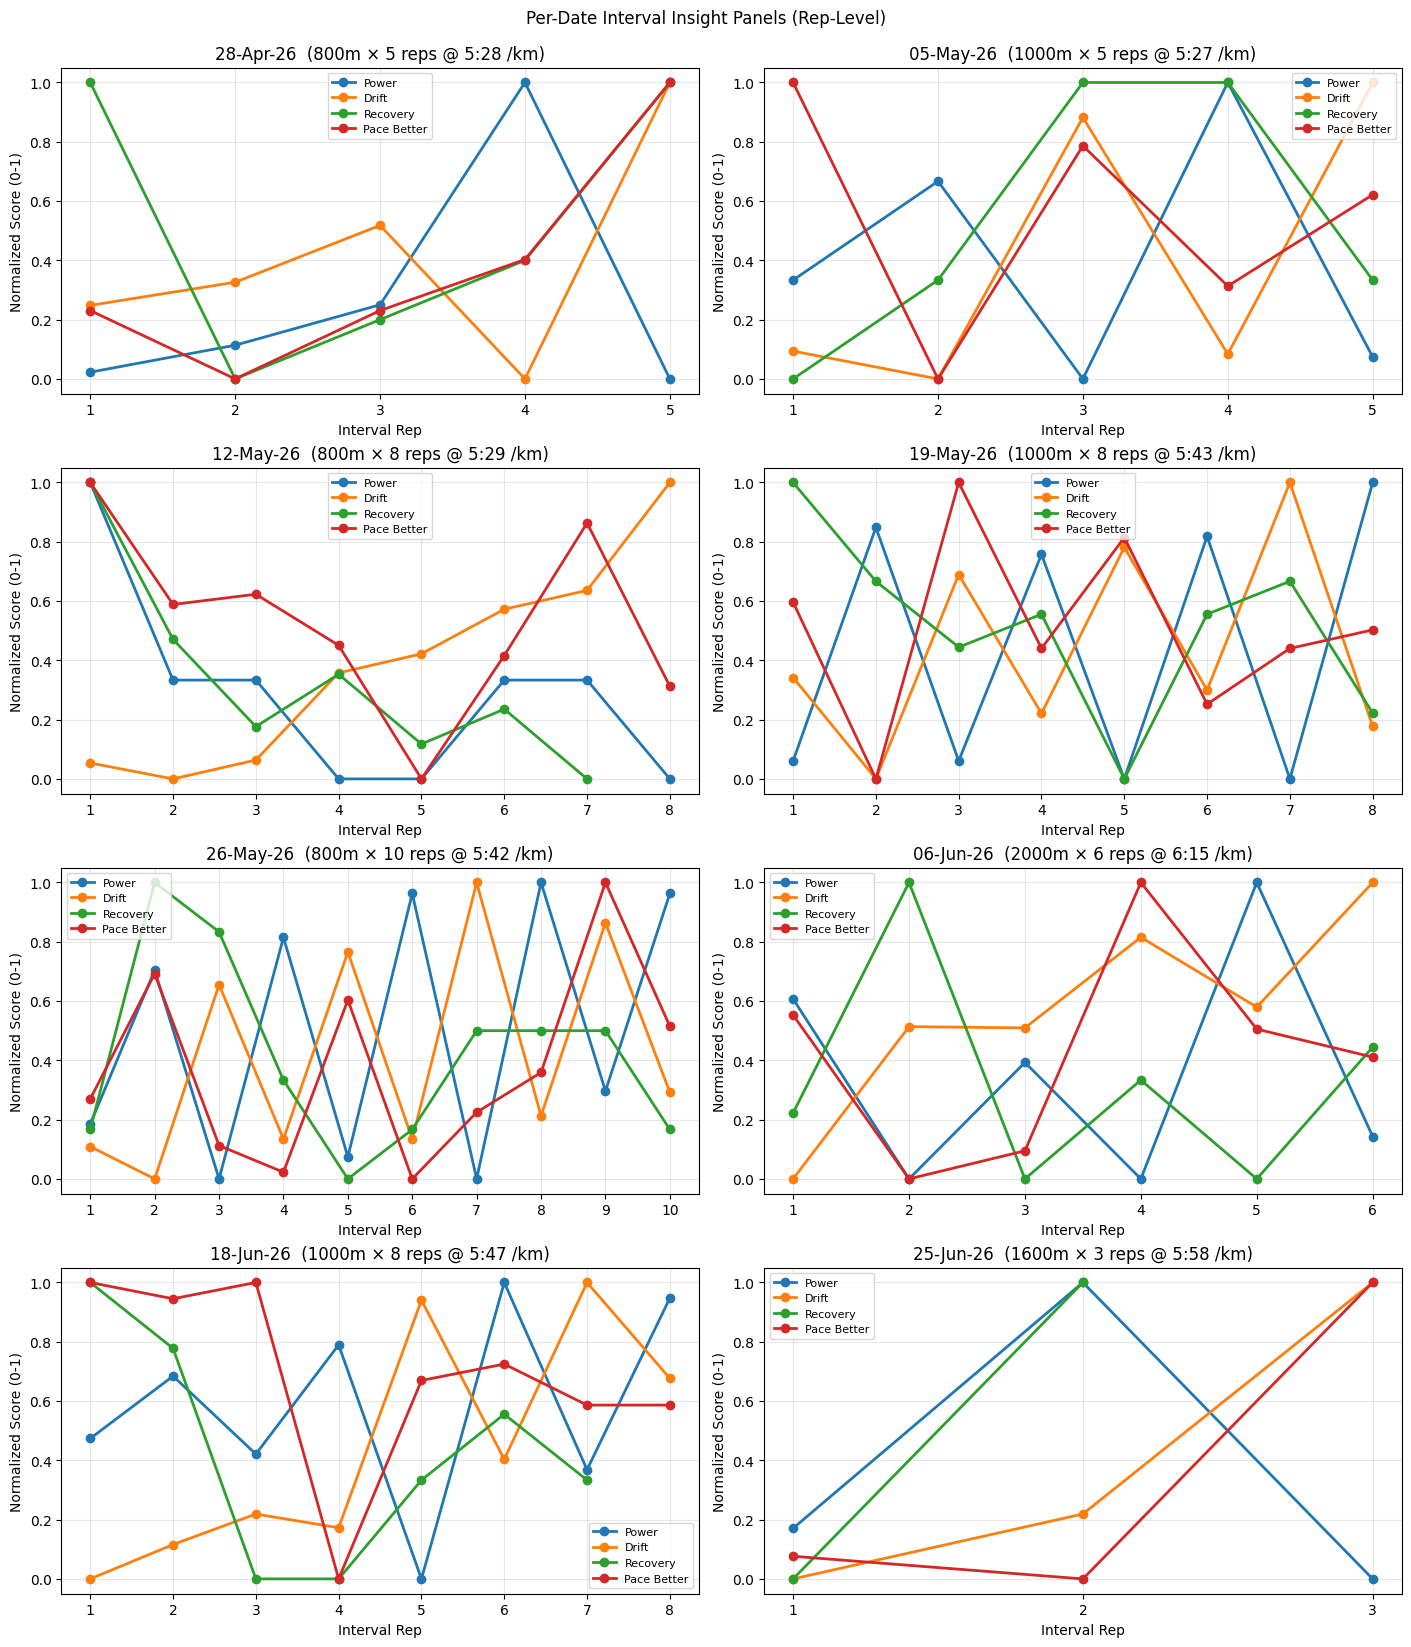

,date_text,file,rep,avg_power,cardiac_drift_pct,hr_recovery_drop_bpm,pace_min_per_km,power_norm,drift_norm,recovery_norm,pace_better_norm
5,05-May-26,2026-05-05_tuesday_interval.fit,1,308.0,0.000000,24.0,5.390254,0.333333,0.093777,0.000000,1.000000
6,05-May-26,2026-05-05_tuesday_interval.fit,2,317.0,-0.982539,25.0,5.529750,0.666667,0.000000,0.333333,0.000000
7,05-May-26,2026-05-05_tuesday_interval.fit,3,299.0,8.258952,27.0,5.420054,0.000000,0.882038,1.000000,0.786375
8,05-May-26,2026-05-05_tuesday_interval.fit,4,326.0,-0.105506,27.0,5.486065,1.000000,0.083707,1.000000,0.313161
9,05-May-26,2026-05-05_tuesday_interval.fit,5,301.0,9.494890,25.0,5.443066,0.074074,1.000000,0.333333,0.621414
36,06-Jun-26,2026-06-06_saturday_interval.fit,1,287.0,0.000000,24.0,6.235192,0.607143,0.000000,0.222222,0.552874
37,06-Jun-26,2026-06-06_saturday_interval.fit,2,278.5,8.221901,31.0,6.276300,0.000000,0.513701,1.000000,0.000000
38,06-Jun-26,2026-06-06_saturday_interval.fit,3,284.0,8.153940,22.0,6.269249,0.392857,0.509455,0.000000,0.094827
39,06-Jun-26,2026-06-06_saturday_interval.fit,4,278.5,13.047081,25.0,6.201947,0.000000,0.815176,0.333333,1.000000
40,06-Jun-26,2026-06-06_saturday_interval.fit,5,292.5,9.277077,22.0,6.238729,1.000000,0.579628,0.000000,0.505304


In [6]:
if 'interval_by_date' not in globals() or interval_by_date.empty:
    raise ValueError('Run Cell 9 first to build interval-only file selection.')

session_rows = []

for _, row in interval_by_date.iterrows():
    file_name = row['file']
    file_path = INTERVAL_DIR / file_name
    if not file_path.exists():
        continue

    parser = FitParser(file_path)
    parser.parse()
    laps_df = parser.laps.copy().reset_index(drop=True)
    if laps_df.empty:
        continue

    laps_df['lap_type'] = laps_df.apply(_lap_label_local, axis=1)
    laps_df['avg_power'] = pd.to_numeric(laps_df.get('avg_power'), errors='coerce')
    laps_df['avg_hr'] = pd.to_numeric(laps_df.get('avg_heart_rate'), errors='coerce')
    laps_df['max_hr'] = pd.to_numeric(laps_df.get('max_heart_rate'), errors='coerce')
    laps_df['distance_m'] = pd.to_numeric(laps_df.get('total_distance'), errors='coerce')
    laps_df['timer_s'] = pd.to_numeric(laps_df.get('total_timer_time'), errors='coerce')
    laps_df['pace_min_per_km'] = laps_df.apply(_pace_min_per_km_numeric_local, axis=1)

    reps_df = _build_reps_from_laps(laps_df)
    if reps_df.empty:
        continue

    reps_df['hr_recovery_drop_bpm'] = reps_df['max_hr'] - reps_df['recovery_avg_hr']
    reps_df['hr_power_ratio'] = reps_df['avg_hr'] / reps_df['avg_power']
    first_ratio = reps_df['hr_power_ratio'].iloc[0] if pd.notna(reps_df['hr_power_ratio'].iloc[0]) else np.nan
    if pd.notna(first_ratio) and first_ratio != 0:
        reps_df['cardiac_drift_pct'] = (reps_df['hr_power_ratio'] / first_ratio - 1.0) * 100.0
    else:
        reps_df['cardiac_drift_pct'] = np.nan

    start_candidates = pd.to_datetime(laps_df.get('start_time'), errors='coerce').dropna()
    if len(start_candidates) > 0:
        workout_dt = start_candidates.sort_values().iloc[len(start_candidates) // 2]
    else:
        workout_dt = pd.to_datetime(file_path.stat().st_mtime, unit='s')

    reps_df['date'] = workout_dt.normalize()
    reps_df['date_text'] = workout_dt.strftime('%d-%b-%y')
    reps_df['file'] = file_name
    session_rows.append(reps_df)

if not session_rows:
    raise ValueError('No rep-level interval data found for per-date charts.')

rep_detail = pd.concat(session_rows, ignore_index=True)

# Normalize inside each date so each subplot shows within-workout interval pattern.
rep_detail['power_norm'] = rep_detail.groupby('date_text')['avg_power'].transform(_minmax_local)
rep_detail['drift_norm'] = rep_detail.groupby('date_text')['cardiac_drift_pct'].transform(_minmax_local)
rep_detail['recovery_norm'] = rep_detail.groupby('date_text')['hr_recovery_drop_bpm'].transform(_minmax_local)
rep_detail['pace_better_norm'] = rep_detail.groupby('date_text')['pace_min_per_km'].transform(lambda s: _minmax_local(-s))

date_order = sorted(rep_detail['date_text'].unique(), key=lambda d: pd.to_datetime(d, format='%d-%b-%y'))
n = len(date_order)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for idx, date_text in enumerate(date_order):
    ax = axes[idx]
    d = rep_detail[rep_detail['date_text'] == date_text].sort_values('rep')

    rep_count = len(d)
    median_dist_m = int(round(pd.to_numeric(d['run_distance_m'], errors='coerce').median()))
    avg_pace_raw = pd.to_numeric(d['pace_min_per_km'], errors='coerce').mean(skipna=True)
    if pd.notna(avg_pace_raw):
        pace_min = int(avg_pace_raw)
        pace_sec = int(round((avg_pace_raw - pace_min) * 60))
        if pace_sec == 60:
            pace_min += 1
            pace_sec = 0
        pace_str = f'{pace_min}:{pace_sec:02d} /km'
    else:
        pace_str = '?:?? /km'

    subplot_title = f'{date_text}  ({median_dist_m}m \u00d7 {rep_count} reps @ {pace_str})'

    ax.plot(d['rep'], d['power_norm'], marker='o', linewidth=2, label='Power')
    ax.plot(d['rep'], d['drift_norm'], marker='o', linewidth=2, label='Drift')
    ax.plot(d['rep'], d['recovery_norm'], marker='o', linewidth=2, label='Recovery')
    ax.plot(d['rep'], d['pace_better_norm'], marker='o', linewidth=2, label='Pace Better')

    ax.set_title(subplot_title)
    ax.set_xlabel('Interval Rep')
    ax.set_ylabel('Normalized Score (0-1)')
    ax.set_xticks(d['rep'])
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8)

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle('Per-Date Interval Insight Panels (Rep-Level)', y=1.02)
plt.show()

display(
    rep_detail[[
        'date_text',
        'file',
        'rep',
        'avg_power',
        'cardiac_drift_pct',
        'hr_recovery_drop_bpm',
        'pace_min_per_km',
        'power_norm',
        'drift_norm',
        'recovery_norm',
        'pace_better_norm',
    ]].sort_values(['date_text', 'rep'])
)

In [7]:
TARGET_DEBUG_DATE = '28-Apr-26'

if 'rep_detail' not in globals() or rep_detail.empty:
    raise ValueError('Run Cell 11 first to build rep_detail.')

debug_df = rep_detail[rep_detail['date_text'] == TARGET_DEBUG_DATE].copy().sort_values('rep')
if debug_df.empty:
    raise ValueError(f'No rows found for {TARGET_DEBUG_DATE}.')

print(f'Debug normalization tables for {TARGET_DEBUG_DATE}')

# 1) Power
p_min = pd.to_numeric(debug_df['avg_power'], errors='coerce').min()
p_max = pd.to_numeric(debug_df['avg_power'], errors='coerce').max()
p_table = debug_df[['rep', 'avg_power', 'power_norm']].copy()
p_table['min_power'] = p_min
p_table['max_power'] = p_max
p_table['calc_power_norm'] = (p_table['avg_power'] - p_min) / (p_max - p_min) if p_max != p_min else 0.0
p_table = p_table[['rep', 'avg_power', 'min_power', 'max_power', 'calc_power_norm', 'power_norm']]

# 2) Drift
# Source: cardiac_drift_pct = ((hr_power_ratio / first_rep_hr_power_ratio) - 1) * 100
d_min = pd.to_numeric(debug_df['cardiac_drift_pct'], errors='coerce').min()
d_max = pd.to_numeric(debug_df['cardiac_drift_pct'], errors='coerce').max()
d_table = debug_df[['rep', 'avg_hr', 'avg_power', 'cardiac_drift_pct', 'drift_norm']].copy()
d_table['hr_power_ratio'] = d_table['avg_hr'] / d_table['avg_power']
first_ratio = d_table.loc[d_table['rep'] == d_table['rep'].min(), 'hr_power_ratio'].iloc[0]
d_table['first_rep_hr_power_ratio'] = first_ratio
d_table['calc_cardiac_drift_pct'] = ((d_table['hr_power_ratio'] / first_ratio) - 1.0) * 100.0
ndenom = (d_max - d_min)
d_table['min_drift_pct'] = d_min
d_table['max_drift_pct'] = d_max
d_table['calc_drift_norm'] = (d_table['cardiac_drift_pct'] - d_min) / ndenom if ndenom != 0 else 0.0
d_table = d_table[[
    'rep',
    'avg_hr',
    'avg_power',
    'hr_power_ratio',
    'first_rep_hr_power_ratio',
    'calc_cardiac_drift_pct',
    'cardiac_drift_pct',
    'min_drift_pct',
    'max_drift_pct',
    'calc_drift_norm',
    'drift_norm',
]]

# 3) Recovery
r_min = pd.to_numeric(debug_df['hr_recovery_drop_bpm'], errors='coerce').min()
r_max = pd.to_numeric(debug_df['hr_recovery_drop_bpm'], errors='coerce').max()
r_table = debug_df[['rep', 'max_hr', 'recovery_avg_hr', 'hr_recovery_drop_bpm', 'recovery_norm']].copy()
r_table['calc_hr_recovery_drop_bpm'] = r_table['max_hr'] - r_table['recovery_avg_hr']
r_table['min_recovery_drop'] = r_min
r_table['max_recovery_drop'] = r_max
r_table['calc_recovery_norm'] = (
    (r_table['hr_recovery_drop_bpm'] - r_min) / (r_max - r_min)
    if r_max != r_min else 0.0
)
r_table = r_table[[
    'rep',
    'max_hr',
    'recovery_avg_hr',
    'calc_hr_recovery_drop_bpm',
    'hr_recovery_drop_bpm',
    'min_recovery_drop',
    'max_recovery_drop',
    'calc_recovery_norm',
    'recovery_norm',
]]

# 4) Pace Better
# pace_better_norm is min-max of (-pace_min_per_km)
inv_pace = -pd.to_numeric(debug_df['pace_min_per_km'], errors='coerce')
pb_min = inv_pace.min()
pb_max = inv_pace.max()
pb_table = debug_df[['rep', 'pace_min_per_km', 'pace_better_norm']].copy()
pb_table['inv_pace'] = -pb_table['pace_min_per_km']
pb_table['min_inv_pace'] = pb_min
pb_table['max_inv_pace'] = pb_max
pb_table['calc_pace_better_norm'] = (
    (pb_table['inv_pace'] - pb_min) / (pb_max - pb_min)
    if pb_max != pb_min else 0.0
)
pb_table = pb_table[[
    'rep',
    'pace_min_per_km',
    'inv_pace',
    'min_inv_pace',
    'max_inv_pace',
    'calc_pace_better_norm',
    'pace_better_norm',
]]

print('\n1) POWER TABLE')
display(p_table)

print('\n2) DRIFT TABLE')
display(d_table)

print('\n3) RECOVERY TABLE')
display(r_table)

print('\n4) PACE BETTER TABLE')
display(pb_table)

Debug normalization tables for 28-Apr-26

1) POWER TABLE


,rep,avg_power,min_power,max_power,calc_power_norm,power_norm
0,1,303.0,302.0,346.0,0.022727,0.022727
1,2,307.0,302.0,346.0,0.113636,0.113636
2,3,313.0,302.0,346.0,0.250000,0.250000
3,4,346.0,302.0,346.0,1.000000,1.000000
4,5,302.0,302.0,346.0,0.000000,0.000000



2) DRIFT TABLE


,rep,avg_hr,avg_power,hr_power_ratio,first_rep_hr_power_ratio,calc_cardiac_drift_pct,cardiac_drift_pct,min_drift_pct,max_drift_pct,calc_drift_norm,drift_norm
0,1,155.0,303.0,0.511551,0.511551,0.000000,0.000000,-3.953011,11.982482,0.248063,0.248063
1,2,159.0,307.0,0.517915,0.511551,1.244090,1.244090,-3.953011,11.982482,0.326134,0.326134
2,3,167.0,313.0,0.533546,0.511551,4.299701,4.299701,-3.953011,11.982482,0.517882,0.517882
3,4,170.0,346.0,0.491329,0.511551,-3.953011,-3.953011,-3.953011,11.982482,0.000000,0.000000
4,5,173.0,302.0,0.572848,0.511551,11.982482,11.982482,-3.953011,11.982482,1.000000,1.000000



3) RECOVERY TABLE


,rep,max_hr,recovery_avg_hr,calc_hr_recovery_drop_bpm,hr_recovery_drop_bpm,min_recovery_drop,max_recovery_drop,calc_recovery_norm,recovery_norm
0,1,168.0,138.0,30.0,30.0,25.0,30.0,1.0,1.0
1,2,172.0,147.0,25.0,25.0,25.0,30.0,0.0,0.0
2,3,177.0,151.0,26.0,26.0,25.0,30.0,0.2,0.2
3,4,180.0,153.0,27.0,27.0,25.0,30.0,0.4,0.4
4,5,185.0,155.0,30.0,30.0,25.0,30.0,1.0,1.0



4) PACE BETTER TABLE


,rep,pace_min_per_km,inv_pace,min_inv_pace,max_inv_pace,calc_pace_better_norm,pace_better_norm
0,1,5.471657,-5.471657,-5.486065,-5.423582,0.230598,0.230598
1,2,5.486065,-5.486065,-5.486065,-5.423582,0.000000,0.000000
2,3,5.471657,-5.471657,-5.486065,-5.423582,0.230598,0.230598
3,4,5.460900,-5.460900,-5.486065,-5.423582,0.402752,0.402752
4,5,5.423582,-5.423582,-5.486065,-5.423582,1.000000,1.000000


## 28-Apr-26 Metric Logic Walkthrough

This section documents each metric separately for 28-Apr-26 with:
- formula
- calculation table
- interpretation

In [8]:
TARGET_DEBUG_DATE = '28-Apr-26'

if 'rep_detail' not in globals() or rep_detail.empty:
    raise ValueError('Run Cell 11 first to build rep_detail.')

debug_df = rep_detail[rep_detail['date_text'] == TARGET_DEBUG_DATE].copy().sort_values('rep')
if debug_df.empty:
    raise ValueError(f'No rows found for {TARGET_DEBUG_DATE}.')

print(f'Using date: {TARGET_DEBUG_DATE} | reps: {len(debug_df)}')
display(debug_df[['rep', 'avg_power', 'avg_hr', 'max_hr', 'recovery_avg_hr', 'pace_min_per_km']])

Using date: 28-Apr-26 | reps: 5


,rep,avg_power,avg_hr,max_hr,recovery_avg_hr,pace_min_per_km
0,1,303.0,155.0,168.0,138.0,5.471657
1,2,307.0,159.0,172.0,147.0,5.486065
2,3,313.0,167.0,177.0,151.0,5.471657
3,4,346.0,170.0,180.0,153.0,5.460900
4,5,302.0,173.0,185.0,155.0,5.423582


### Logic 1: Power

Formula

power_norm = (avg_power - min(avg_power)) / (max(avg_power) - min(avg_power))

Interpretation

- 1.0 = highest-power rep of the date
- 0.0 = lowest-power rep of the date

Power interpretation: higher normalized value means stronger power output within this date.


,rep,avg_power,min_power,max_power,calc_power_norm,stored_power_norm
0,1,303.0,302.0,346.0,0.022727,0.022727
1,2,307.0,302.0,346.0,0.113636,0.113636
2,3,313.0,302.0,346.0,0.250000,0.250000
3,4,346.0,302.0,346.0,1.000000,1.000000
4,5,302.0,302.0,346.0,0.000000,0.000000


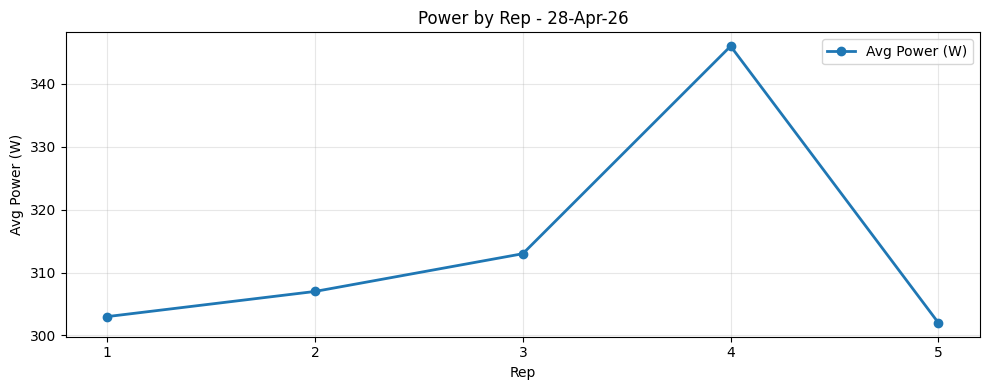

In [9]:
p_min = pd.to_numeric(debug_df['avg_power'], errors='coerce').min()
p_max = pd.to_numeric(debug_df['avg_power'], errors='coerce').max()

power_table = debug_df[['rep', 'avg_power']].copy()
power_table['min_power'] = p_min
power_table['max_power'] = p_max
power_table['calc_power_norm'] = (power_table['avg_power'] - p_min) / (p_max - p_min) if p_max != p_min else 0.0
power_table['stored_power_norm'] = debug_df['power_norm'].values

print('Power interpretation: higher normalized value means stronger power output within this date.')
display(power_table)

plt.figure(figsize=(10, 4))
plt.plot(power_table['rep'], power_table['avg_power'], marker='o', linewidth=2, label='Avg Power (W)')
plt.title('Power by Rep - 28-Apr-26')
plt.xlabel('Rep')
plt.ylabel('Avg Power (W)')
plt.xticks(power_table['rep'])
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Logic 2: Drift

Formula

hr_power_ratio = avg_hr / avg_power

cardiac_drift_pct = ((hr_power_ratio / first_rep_hr_power_ratio) - 1) * 100

drift_norm = (cardiac_drift_pct - min(cardiac_drift_pct)) / (max(cardiac_drift_pct) - min(cardiac_drift_pct))

Interpretation

- Positive drift = higher HR cost per watt versus first rep
- Higher norm value = worse cardiovascular efficiency within the date

Drift interpretation: higher normalized value means more cardiovascular drift in that rep.


,rep,avg_hr,avg_power,cardiac_drift_pct,hr_power_ratio,first_rep_hr_power_ratio,calc_cardiac_drift_pct,min_drift_pct,max_drift_pct,calc_drift_norm,stored_drift_norm
0,1,155.0,303.0,0.000000,0.511551,0.511551,0.000000,-3.953011,11.982482,0.248063,0.248063
1,2,159.0,307.0,1.244090,0.517915,0.511551,1.244090,-3.953011,11.982482,0.326134,0.326134
2,3,167.0,313.0,4.299701,0.533546,0.511551,4.299701,-3.953011,11.982482,0.517882,0.517882
3,4,170.0,346.0,-3.953011,0.491329,0.511551,-3.953011,-3.953011,11.982482,0.000000,0.000000
4,5,173.0,302.0,11.982482,0.572848,0.511551,11.982482,-3.953011,11.982482,1.000000,1.000000


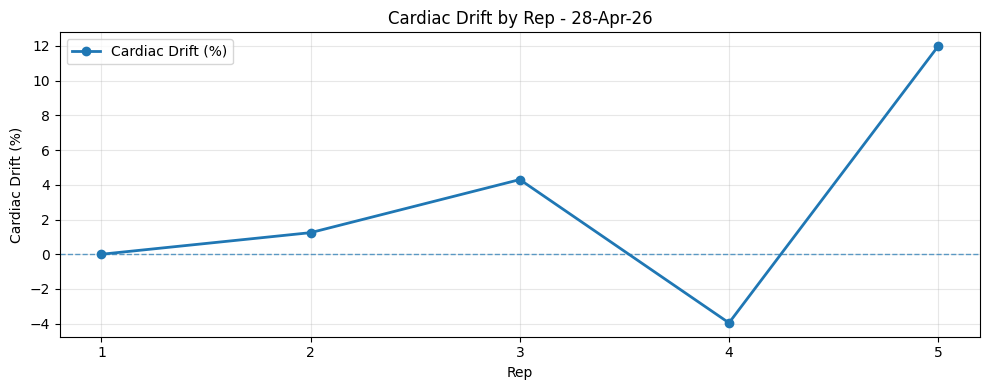

In [10]:
drift_table = debug_df[['rep', 'avg_hr', 'avg_power', 'cardiac_drift_pct']].copy()
drift_table['hr_power_ratio'] = drift_table['avg_hr'] / drift_table['avg_power']
first_ratio = drift_table.loc[drift_table['rep'] == drift_table['rep'].min(), 'hr_power_ratio'].iloc[0]
drift_table['first_rep_hr_power_ratio'] = first_ratio
drift_table['calc_cardiac_drift_pct'] = ((drift_table['hr_power_ratio'] / first_ratio) - 1.0) * 100.0

d_min = pd.to_numeric(drift_table['cardiac_drift_pct'], errors='coerce').min()
d_max = pd.to_numeric(drift_table['cardiac_drift_pct'], errors='coerce').max()
drift_table['min_drift_pct'] = d_min
drift_table['max_drift_pct'] = d_max
drift_table['calc_drift_norm'] = (drift_table['cardiac_drift_pct'] - d_min) / (d_max - d_min) if d_max != d_min else 0.0
drift_table['stored_drift_norm'] = debug_df['drift_norm'].values

print('Drift interpretation: higher normalized value means more cardiovascular drift in that rep.')
display(drift_table)

plt.figure(figsize=(10, 4))
plt.plot(drift_table['rep'], drift_table['cardiac_drift_pct'], marker='o', linewidth=2, label='Cardiac Drift (%)')
plt.axhline(0, linestyle='--', linewidth=1, alpha=0.7)
plt.title('Cardiac Drift by Rep - 28-Apr-26')
plt.xlabel('Rep')
plt.ylabel('Cardiac Drift (%)')
plt.xticks(drift_table['rep'])
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Logic 3: Recovery

Formula

hr_recovery_drop_bpm = max_hr(run rep) - recovery_avg_hr(next recovery lap)

recovery_norm = (hr_recovery_drop_bpm - min(hr_recovery_drop_bpm)) / (max(hr_recovery_drop_bpm) - min(hr_recovery_drop_bpm))

Interpretation

- Larger drop generally indicates better between-rep recovery
- Higher norm value = stronger recovery response within the date

Recovery interpretation: higher normalized value means larger HR drop after the run rep.


,rep,max_hr,recovery_avg_hr,hr_recovery_drop_bpm,calc_hr_recovery_drop_bpm,min_recovery_drop,max_recovery_drop,calc_recovery_norm,stored_recovery_norm
0,1,168.0,138.0,30.0,30.0,25.0,30.0,1.0,1.0
1,2,172.0,147.0,25.0,25.0,25.0,30.0,0.0,0.0
2,3,177.0,151.0,26.0,26.0,25.0,30.0,0.2,0.2
3,4,180.0,153.0,27.0,27.0,25.0,30.0,0.4,0.4
4,5,185.0,155.0,30.0,30.0,25.0,30.0,1.0,1.0


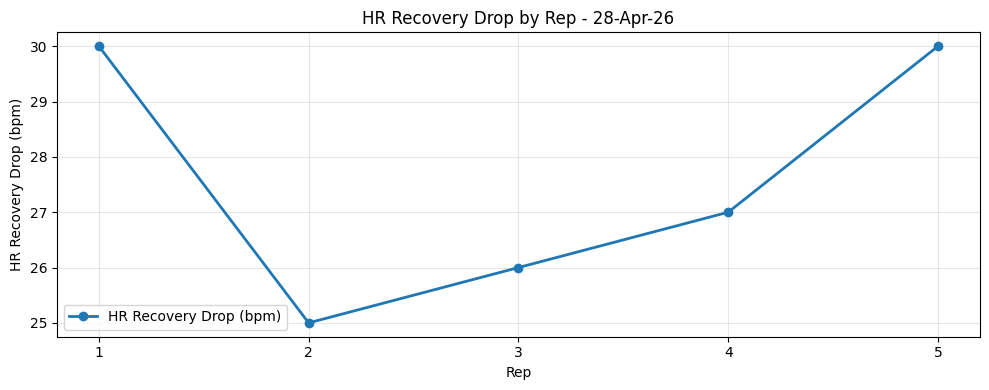

In [11]:
r_min = pd.to_numeric(debug_df['hr_recovery_drop_bpm'], errors='coerce').min()
r_max = pd.to_numeric(debug_df['hr_recovery_drop_bpm'], errors='coerce').max()

recovery_table = debug_df[['rep', 'max_hr', 'recovery_avg_hr', 'hr_recovery_drop_bpm']].copy()
recovery_table['calc_hr_recovery_drop_bpm'] = recovery_table['max_hr'] - recovery_table['recovery_avg_hr']
recovery_table['min_recovery_drop'] = r_min
recovery_table['max_recovery_drop'] = r_max
recovery_table['calc_recovery_norm'] = (recovery_table['hr_recovery_drop_bpm'] - r_min) / (r_max - r_min) if r_max != r_min else 0.0
recovery_table['stored_recovery_norm'] = debug_df['recovery_norm'].values

print('Recovery interpretation: higher normalized value means larger HR drop after the run rep.')
display(recovery_table)

plt.figure(figsize=(10, 4))
plt.plot(recovery_table['rep'], recovery_table['hr_recovery_drop_bpm'], marker='o', linewidth=2, label='HR Recovery Drop (bpm)')
plt.title('HR Recovery Drop by Rep - 28-Apr-26')
plt.xlabel('Rep')
plt.ylabel('HR Recovery Drop (bpm)')
plt.xticks(recovery_table['rep'])
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Logic 4: Pace Better

Formula

inv_pace = -pace_min_per_km

pace_better_norm = (inv_pace - min(inv_pace)) / (max(inv_pace) - min(inv_pace))

Interpretation

- Because lower min/km is better, pace is inverted first
- Higher norm value = faster rep pace within the date

Pace interpretation: higher normalized value means faster rep pace.


,rep,pace_min_per_km,inv_pace,min_inv_pace,max_inv_pace,calc_pace_better_norm,stored_pace_better_norm
0,1,5.471657,-5.471657,-5.486065,-5.423582,0.230598,0.230598
1,2,5.486065,-5.486065,-5.486065,-5.423582,0.000000,0.000000
2,3,5.471657,-5.471657,-5.486065,-5.423582,0.230598,0.230598
3,4,5.460900,-5.460900,-5.486065,-5.423582,0.402752,0.402752
4,5,5.423582,-5.423582,-5.486065,-5.423582,1.000000,1.000000


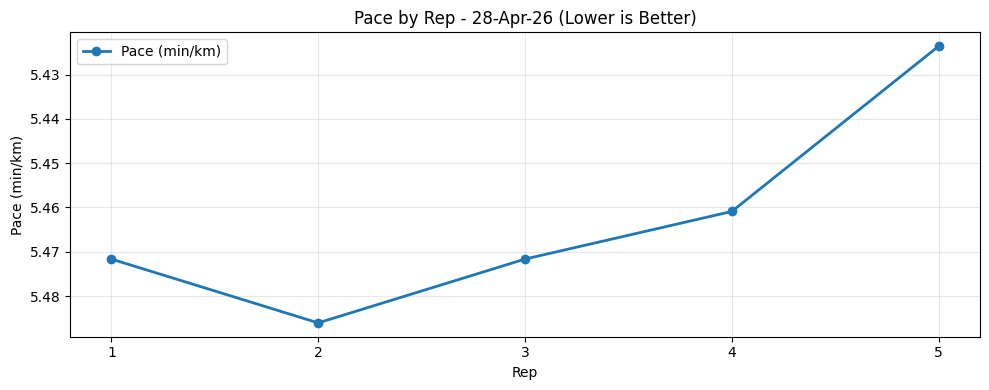

In [12]:
inv_pace = -pd.to_numeric(debug_df['pace_min_per_km'], errors='coerce')
pb_min = inv_pace.min()
pb_max = inv_pace.max()

pace_table = debug_df[['rep', 'pace_min_per_km']].copy()
pace_table['inv_pace'] = -pace_table['pace_min_per_km']
pace_table['min_inv_pace'] = pb_min
pace_table['max_inv_pace'] = pb_max
pace_table['calc_pace_better_norm'] = (pace_table['inv_pace'] - pb_min) / (pb_max - pb_min) if pb_max != pb_min else 0.0
pace_table['stored_pace_better_norm'] = debug_df['pace_better_norm'].values

print('Pace interpretation: higher normalized value means faster rep pace.')
display(pace_table)

plt.figure(figsize=(10, 4))
plt.plot(pace_table['rep'], pace_table['pace_min_per_km'], marker='o', linewidth=2, label='Pace (min/km)')
plt.gca().invert_yaxis()
plt.title('Pace by Rep - 28-Apr-26 (Lower is Better)')
plt.xlabel('Rep')
plt.ylabel('Pace (min/km)')
plt.xticks(pace_table['rep'])
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()